In [1]:
import numpy as np
import pandas as pd
from qiskit import QuantumRegister
from qiskit import ClassicalRegister
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

# Visualizing Noise on Real Quantum Hardware

**Reference & Context:** This notebook implements and tests the noise-diagnostic circuit presented by Zlatko Minev in the talk *"Introduction to the quantum noise"*. The full presentation can be found on [YouTube](https://www.youtube.com/watch?v=3Ka11boCm1M).

## General definitions
We consider a quantum system of $n$ qubits living in a $2^{n}$ dimensional Hilbert space $\mathcal{H}$, which is isomorphic to $\mathbb{C}^{2n}$. This isomorphism enables us to represent a quantum state as a complex column vector that satisfies the normalization condition:

\begin{equation}
\bra{\psi}\ket{\psi}=1
\end{equation}

The ground state and excited state are denoted by $\ket{0}$ and $\ket{1}$, respectively. In the computational basis of $\mathbb{C}^{2}$, these states has the following vector representation:
\begin{equation}
\ket{0} = \begin{pmatrix}
1 \\ 0
\end{pmatrix}, \quad
\ket{1} = \begin{pmatrix}
0 \\ 1
\end{pmatrix}.
\end{equation}

In this experiment, we will manipulate these states using the quantum not gate (X) which flips the state of a qubit:
\begin{equation}
X\ket{0} = \ket{1}, \quad X\ket{1} = \ket{0}.
\end{equation}
Its matrix representation is given by
\begin{equation}
X= \begin{bmatrix}
0 & 1  \\
1 & 0
\end{bmatrix}.
\end{equation}

## Circuit 
Our ideal circuit start with $n$ qubits in the ground state $\ket{0}^{\otimes n}$. We indexx each qubit from $i=0$ to $i=n-1$. According to this numeration, we apply $i$ X gates to the initial state and we measure $\sigma_z$ in all the qubits, where $\sigma_z$ is given by 
\begin{equation}
\sigma_z = \ket{0}\bra{0} - \ket{1}\bra{1}.
\end{equation}
Using this, we can define the quantum state before measurement as
\begin{equation}
\ket{\psi} = X^{i}\ket{0} = \begin{cases}
\ket{0} & \text{if} & i & \text{is even}\\
\ket{1} & \text{if} & i & \text{is odd}
\end{cases}.
\end{equation}
So, the expectation value is given by
\begin{equation}
\langle \sigma_z \rangle  = \bra{\psi} \sigma_z \ket{\psi} = (-1)^{i}
\end{equation}



### Code for making the circuit described above using qiskit

In [2]:
def circuit(n):
    """
    Fuction that  creates a quantum circut with n qubits and n classical registers.

    Parameters
    ----------
    n : int
        Number of qubits and classical registers in the circuit.
    Returns
    -------
    qc : QuantumCircuit
        Quantum circuit with n qubits and n classical registers, where each qubit is measured and
        the result is stored in the corresponding classical register.
    """
    # We create a quantum register named 'q' of n qubits
    q=QuantumRegister(n, 'q')
    #Classical register to save measurments outcomes. Remember, main goal is obtain statistics of all qubits
    c=[ClassicalRegister(1, f'c{i+1}') for i in range(n)]

# As we have n classical registers, we need to unpack them when creating the circuit using the * operator
    qc=QuantumCircuit(q, *c)

    for i in range(n):
        for _ in range(i):
            # This apply a X gate to the i-th qubit, i times. This is equivalent to applying a X gate to the i-th qubit if i is odd, and doing nothing if i is even.
            qc.x(i)
            #We add a barrier to separate the different operations in the circuit. This is not strictly necessary, but it helps to visualize the circuit better.
            qc.barrier(i)
    
    for j in range(n):
        # We measure the j-th qubit and store the result in the j-th classical register
        qc.measure(j,j)
    return qc

#### Picture of the circuit for ten qubits

In [3]:
qc = circuit(5)

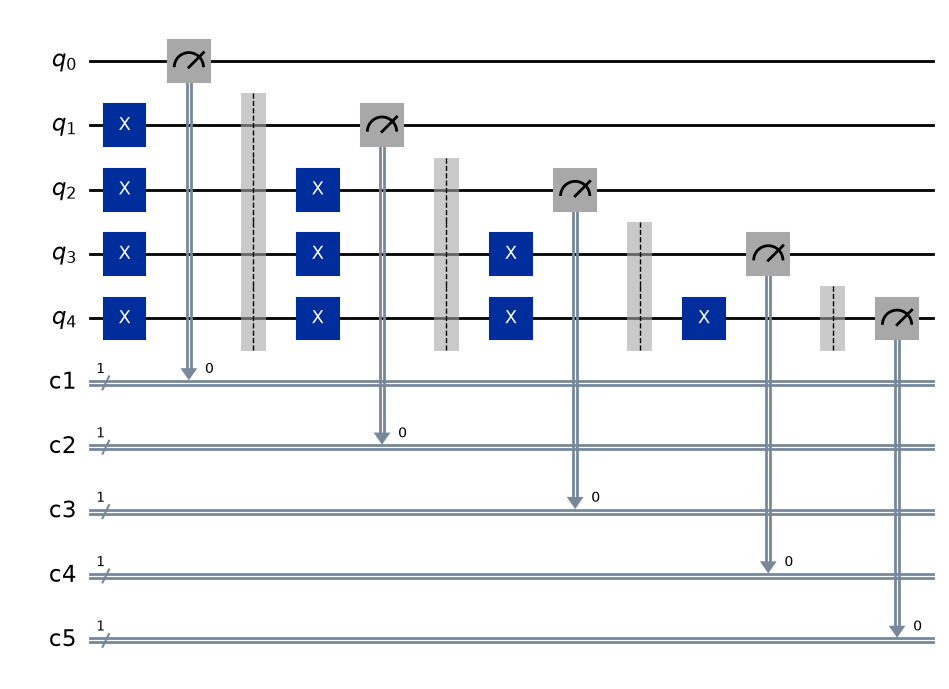

In [4]:
#We show an example of how the circuit looks like. The output is a matplotlib figure.
qc.draw(output="mpl")

In [5]:
#The idea is to work with 101 qubits.
qc=circuit(101)

In [6]:
#We can use the Qiskit Runtime Service to find the least busy backend that is operational and not a simulator. 
# We can then generate a preset pass manager with optimization level 0 for that backend. 
# This means that the transpiler will not perform any optimizations on the circuit.
# Finally, we can run the pass manager on our circuit to get the transpiled circuit.
#Transpiled the circuit makes it more readable for the backend.
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend= QiskitRuntimeService().least_busy(operational=True, simulator=False)
pass_manager= generate_preset_pass_manager(optimization_level=0, backend=backend)

cir=pass_manager.run(qc)

In [ ]:
# Quantum computer used for the experiment"
print(backend)

<IBMBackend('ibm_marrakesh')>


In [9]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

#sampler is a runtime primitive that allows us to run circuits on a backend and get the results. 
# We can specify the backend we want to use when creating the sampler. 
# We can also specify the number of shots we want to run for each circuit. 
sampler=Sampler(mode= backend)
sampler.options.default_shots=4096
job=sampler.run([cir])
#We can get the job id to track the job status in the IBM Quantum dashboard.
job_id=job.job_id()
print(job_id)

da1t9ksdedkc73erg240


In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService is a class that allows us to interact with the IBM Quantum cloud. We can use it to find the least busy backend, run circuits, and get results.
service=QiskitRuntimeService()

In [7]:
job_id='da1t9ksdedkc73erg240'
# We obtain the job object using the job id.
job = service.job(job_id)
job_result = job.result()

# This part of code is to obtain the counts of each classical register,
pub_result = job.result()[0]

all_counts = []

# We loop through the classical registers and get the counts for each one. We store the counts in a list of dictionaries.
for i in range(1, 102):  
    counts = pub_result.data[f'c{i}'].get_counts()
    all_counts.append(counts)



### Data analyst 

In [8]:
# We use pandas to analyze the counts.
import pandas as pd

In [9]:

def dataframes(Counts):
    """
    Function that takes a list of dictionaries (Counts) as input, where each dictionary contains the measurement results and their frequencies for a classical register. 
    It converts each dictionary into a pandas DataFrame with two columns: 'Resultado de medición' (measurement result) and 'Frecuencia' (frequency). 
    
    Parameters
    ----------
    Counts : list of dict
        A list of dictionaries, where each dictionary contains the measurement results and their frequencies for a classical register.

    Returns
    -------
    Df : list of pandas.DataFrame
        A list of DataFrames, where each DataFrame corresponds to a classical register and containst the mesurement results and their frequencies.
    """
    Df=[]
    for j in range(len(Counts)):
        Df.append(pd.DataFrame(Counts[j].items(), columns=['Resultado de medición', 'Frecuencia']))
    
    return Df

In [10]:
df_classical_registers= dataframes(all_counts)

In [11]:

def exp_value(df, N):
    """
    This calculates the expected values for each classical register based on the measurment results and their frequencies.
    The expedcted values is is calculated using the formula:
    E[X] = Σ(x * P(x)),
    where x is the measurement result (0 or 1) and P(x) is the probability of obtaining that result, which is calculated as the frequency of that result divided by N (the total number of shots).

    parameters
    ----------
    df : list of pandas.DataFrame
         A list of DataFrames, where each DataFrame corresponds to a classical register and contains the measurement results and their frequencies.
    N :  int
        Total number of shots (measurements) performed for each classical register.
    
    Returns
    -------
    ex_v : list of float
        A list of expected values for each classical register.
    """
    ex_v=[0]*len(df)
    for j in range(len(df)):
        if df[j]['Resultado de medición'][0]=='0':
            ex_v[j]= 2*df[j]['Frecuencia'][0]/N -1
        else:
            ex_v[j]=1-2*df[j]['Frecuencia'][0]/N

    return ex_v

In [12]:
# This function calculates the ideal expected values for each classical register based on the number of qubits.
exp_value_ideal = lambda n: [(-1)**j for j in range(n)]

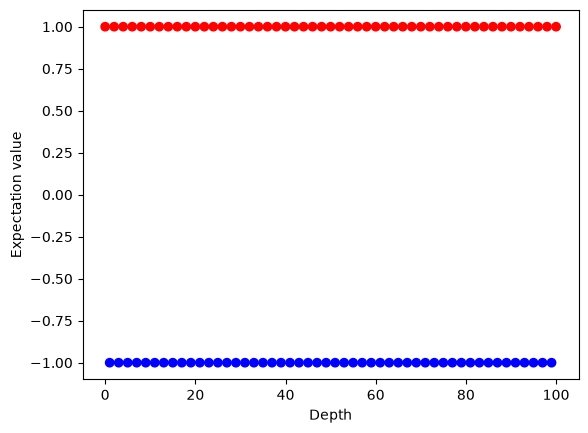

In [13]:

x=range(0, 101) # Number of gates X applied
y=exp_value_ideal(101)

plt.figure()
plt.scatter(x, y,c=y, cmap='bwr', label='Valor esperado')
plt.xlabel('Depth')
plt.ylabel('Expectation value')
plt.savefig('Valor_esperado.png')
#This plot represents the ideal expected values vs number of X gates applied to each qubit.
# Remember the number of X gates applied to each qubit is equal to the index of the qubit. 
# For example, the first qubit (index 0) has 0 X gates applied, the second qubit (index 1) has 1 X gate applied, and so on. 
# Number of X gates in this context refers to the circuit depth.

/var/folders/rn/l81lt25j195c69yjzf24hl2m0000gn/T/ipykernel_3340/2027344173.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


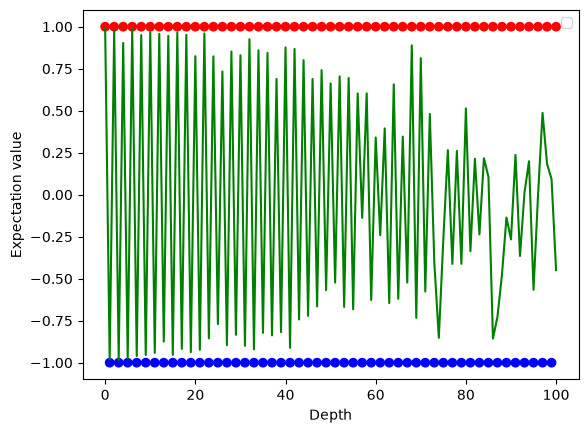

In [14]:
y_data=exp_value(df_classical_registers, 4096) #Expected value calculated from the experimental data obtained from the quantum circuit execution.
plt.figure()
plt.scatter(x,y,c=y, cmap='bwr')
plt.plot(x, y_data, color = "green")
plt.legend()
plt.xlabel('Depth')
plt.ylabel('Expectation value')
plt.savefig('Valor esperado.png')

Ideal expectation value: We have an oscilation between 1 (red points) and -1 (blue points).

Expectation value from data: We observe in the green line how the amplitude of the oscillations decrase with the depht of the circuit.

### Conclussions & discussions 
The results show that the estimated expectation value becomes less accurate as the circuit depth increases. This is consistent with the accumulation of gate errors and decoherence in deeper circuits. Overall, the experiment illustrates how increasing circuit depth can affect the performance of quantum computations on real hardware.